# Julian's Data Analysis Template
This notebook follows a robust, auditable workflow with clearly defined milestones. Update and expand each section as your project progresses.

## Milestone 1: Environment & Library Check

In [30]:
import platform
import sys
import pandas as pd
import pkg_resources
print(f'Python version: {platform.python_version()}')
print(f'Pandas version: {pd.__version__}')
print(f'System: {platform.system()} {platform.release()}')
print(f'Executable: {sys.executable}')

Python version: 3.12.8
Pandas version: 2.3.1
System: Linux 6.8.0-1027-azure
Executable: /workspaces/codespaces-jupyter-python/.venv/bin/python


### Packages Installed

In [31]:
# List all installed libraries in the environment
installed_packages = sorted([(d.project_name, d.version) for d in pkg_resources.working_set])
for name, version in installed_packages:
    print(f'{name}=={version}')

MarkupSafe==3.0.2
PyYAML==6.0.2
Send2Trash==1.8.3
anyio==4.9.0
argon2-cffi==25.1.0
argon2-cffi-bindings==21.2.0
arrow==1.3.0
asttokens==3.0.0
async-lru==2.0.5
attrs==25.3.0
autocommand==2.2.2
babel==2.17.0
backports.tarfile==1.2.0
beautifulsoup4==4.13.4
bleach==6.2.0
certifi==2025.7.14
cffi==1.17.1
charset-normalizer==3.4.2
comm==0.2.2
contourpy==1.3.2
cycler==0.12.1
debugpy==1.8.15
decorator==5.2.1
defusedxml==0.7.1
et-xmlfile==2.0.0
executing==2.2.0
fastjsonschema==2.21.1
fonttools==4.59.0
fqdn==1.5.1
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.10
importlib-metadata==8.0.0
inflect==7.3.1
ipykernel==6.29.5
ipython==9.4.0
ipython-pygments-lexers==1.1.1
ipywidgets==8.1.7
isoduration==20.11.0
jaraco.collections==5.1.0
jaraco.context==5.3.0
jaraco.functools==4.0.1
jaraco.text==3.12.1
jedi==0.19.2
jinja2==3.1.6
joblib==1.5.1
json5==0.12.0
jsonpointer==3.0.0
jsonschema==4.24.1
jsonschema-specifications==2025.4.1
jupyter==1.1.1
jupyter-client==8.6.3
jupyter-console==6.6.3
jupyter-core=

## Helper Code: Data Dictionary Function

In [32]:
# Researched column descriptions for seaborn 'tips' dataset
column_descriptions = {
    'total_bill': 'Total bill (cost of the meal), in US dollars',
    'tip': 'Tip given to the waiter, in US dollars',
    'sex': 'Gender of the bill payer ("Male" or "Female")',
    'smoker': 'Whether there were smokers in the party ("Yes" or "No")',
    'day': 'Day of the week ("Thur", "Fri", "Sat", "Sun")',
    'time': 'Time of day ("Lunch" or "Dinner")',
    'size': 'Size of the dining party (number of people)'
}

def create_data_dictionary(df, descriptions=None):
    """
    Creates a data dictionary for the given DataFrame.
    Args:
        df (pd.DataFrame): The DataFrame to analyze.
        descriptions (dict): Optional. Dictionary of column descriptions.
    Returns:
        pd.DataFrame: Data dictionary.
    """
    if descriptions is None:
        descriptions = {}
    dictionary_data = []
    for column in df.columns:
        sample_values = df[column].dropna().head(3).tolist()
        sample_str = ', '.join([str(x) for x in sample_values])
        dictionary_data.append({
            'Column': column,
            'Data Type': str(df[column].dtype),
            'Missing Values': df[column].isnull().sum(),
            'Missing %': round((df[column].isnull().sum() / len(df)) * 100, 2),
            'Unique Values': df[column].nunique(),
            'Sample Values': sample_str,
            'Description': descriptions.get(column, 'Description: [To be defined]')
        })
    return pd.DataFrame(dictionary_data)

## Helper Code: Logging Conversion Function

In [33]:
def log_conversion_errors(df, column, conversion_func, **kwargs):
    """
    Attempts to convert a column using the provided conversion function and logs values that fail conversion.
    Args:
        df (pd.DataFrame): The DataFrame containing the column.
        column (str): The column name to convert.
        conversion_func (callable): The pandas conversion function (e.g., pd.to_numeric, pd.to_datetime).
        **kwargs: Additional keyword arguments for the conversion function.
    Returns:
        pd.Series: The converted column.
    """
    original = df[column]
    converted = conversion_func(original, **kwargs)
    failed_mask = converted.isna() & original.notna()
    if failed_mask.any():
        print(f"Values that failed conversion in '{column}':")
        display(df.loc[failed_mask, [column]])
        for idx, val in df.loc[failed_mask, column].items():
            print(f"Row {idx}: {val!r}")
    else:
        print(f"No conversion errors detected in '{column}'.")
    return converted

# Example usage:
## Uncomment and modify as needed
# df['your_column'] = log_conversion_errors(df, 'your_column', pd.to_numeric, errors='coerce')
# df['your_date_column'] = log_conversion_errors(df, 'your_date_column', pd.to_datetime, errors='coerce')

## Helper Code: EDA Visualization Function

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def perform_eda(df, show_outlier_boundaries=True, max_pairplot_cols=5):
    """
    Performs comprehensive Exploratory Data Analysis on a DataFrame.
    Args:
        df (pd.DataFrame): The DataFrame to analyze.
        show_outlier_boundaries (bool): Whether to show outlier boundary lines on distributions.
        max_pairplot_cols (int): Maximum number of numeric columns for pairplot (to avoid overcrowding).
    """
    # Set up plotting style
    plt.style.use('default')
    sns.set_palette('husl')
    
    # Get numeric and categorical columns
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f'Numeric columns: {numeric_cols}')
    print(f'Categorical columns: {categorical_cols}')
    print(f'Total columns analyzed: {len(numeric_cols) + len(categorical_cols)}')
    
    # 1. Distribution plots for numeric columns
    if numeric_cols:
        print('\n=== NUMERIC DISTRIBUTIONS ===')
        n_numeric = len(numeric_cols)
        fig, axes = plt.subplots(nrows=(n_numeric + 2) // 3, ncols=3, figsize=(15, 5 * ((n_numeric + 2) // 3)))
        axes = axes.flatten() if n_numeric > 1 else [axes]
        
        for i, col in enumerate(numeric_cols):
            # Create histogram with KDE
            sns.histplot(data=df, x=col, kde=True, ax=axes[i])
            
            if show_outlier_boundaries:
                # Calculate outlier boundaries
                Q1 = df[col].quantile(0.25)
                Q3 = df[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                
                # Add vertical lines for outlier boundaries
                axes[i].axvline(lower_bound, color='red', linestyle='--', alpha=0.7, label=f'Lower ({lower_bound:.2f})')
                axes[i].axvline(upper_bound, color='red', linestyle='--', alpha=0.7, label=f'Upper ({upper_bound:.2f})')
                
                # Count outliers
                outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
                axes[i].set_title(f'{col}\n{len(outliers)} outliers ({(len(outliers)/len(df)*100):.1f}%)')
                axes[i].legend(fontsize=8)
            else:
                axes[i].set_title(f'Distribution of {col}')
        
        # Hide empty subplots
        for i in range(n_numeric, len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        if show_outlier_boundaries:
            plt.suptitle('Distribution Plots with Outlier Boundaries (IQR Method)', y=1.02)
        else:
            plt.suptitle('Distribution Plots for Numeric Variables', y=1.02)
        plt.show()
    
    # 2. Frequency plots for categorical columns
    if categorical_cols:
        print('\n=== CATEGORICAL FREQUENCIES ===')
        n_categorical = len(categorical_cols)
        fig, axes = plt.subplots(nrows=(n_categorical + 2) // 3, ncols=3, figsize=(15, 5 * ((n_categorical + 2) // 3)))
        axes = axes.flatten() if n_categorical > 1 else [axes]
        
        for i, col in enumerate(categorical_cols):
            value_counts = df[col].value_counts()
            axes[i].bar(range(len(value_counts)), value_counts.values)
            axes[i].set_xticks(range(len(value_counts)))
            axes[i].set_xticklabels(value_counts.index, rotation=45)
            axes[i].set_title(f'Frequency of {col}')
            axes[i].set_ylabel('Count')
        
        # Hide empty subplots
        for i in range(n_categorical, len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.suptitle('Frequency Plots for Categorical Variables', y=1.02)
        plt.show()
    
    # 3. Correlation matrix for numeric columns
    if len(numeric_cols) > 1:
        print('\n=== CORRELATION ANALYSIS ===')
        plt.figure(figsize=(10, 8))
        correlation_matrix = df[numeric_cols].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                    square=True, linewidths=0.5)
        plt.title('Correlation Matrix of Numeric Variables')
        plt.tight_layout()
        plt.show()
    
    # 4. Pairplot for numeric variables (if not too many)
    if len(numeric_cols) <= max_pairplot_cols and len(numeric_cols) > 1:
        print('\n=== PAIRWISE RELATIONSHIPS ===')
        sns.pairplot(df[numeric_cols], diag_kind='kde')
        plt.suptitle('Pairwise Relationships of Numeric Variables', y=1.02)
        plt.show()
    elif len(numeric_cols) > max_pairplot_cols:
        print(f'\nSkipping pairplot: {len(numeric_cols)} numeric columns > {max_pairplot_cols} (would be too crowded)')
    
    print('\n=== EDA COMPLETE ===')
    print(f'Analyzed {len(numeric_cols)} numeric and {len(categorical_cols)} categorical columns')

# Example usage:
## Call this function in your EDA milestone:
# perform_eda(df, show_outlier_boundaries=True, max_pairplot_cols=5)

## Milestone 2: Data Loading
*Load your data here. For demonstration, a seaborn sample dataset is used as a placeholder. Replace with your own data source as needed.*

In [35]:
import seaborn as sns
# Load your dataset
df = sns.load_dataset('penguins')
print('Sample data loaded. Shape:', df.shape)

# Display the first few rows of the dataset
df.head()

Sample data loaded. Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [36]:
# Researched column descriptions for seaborn 'tips' dataset
column_descriptions = {
    'total_bill': 'Total bill (cost of the meal), in US dollars',
    'tip': 'Tip given to the waiter, in US dollars',
    'sex': 'Gender of the bill payer ("Male" or "Female")',
    'smoker': 'Whether there were smokers in the party ("Yes" or "No")',
    'day': 'Day of the week ("Thur", "Fri", "Sat", "Sun")',
    'time': 'Time of day ("Lunch" or "Dinner")',
    'size': 'Size of the dining party (number of people)'
}

In [37]:
# Run the data dictionary function on the loaded dataset
raw_data_dictionary = create_data_dictionary(df, column_descriptions)
raw_data_dictionary

,Column,Data Type,Missing Values,Missing %,Unique Values,Sample Values,Description
0,species,object,0,0.00,3,"Adelie, Adelie, Adelie",Description: [To be defined]
1,island,object,0,0.00,3,"Torgersen, Torgersen, Torgersen",Description: [To be defined]
2,bill_length_mm,float64,2,0.58,164,"39.1, 39.5, 40.3",Description: [To be defined]
3,bill_depth_mm,float64,2,0.58,80,"18.7, 17.4, 18.0",Description: [To be defined]
4,flipper_length_mm,float64,2,0.58,55,"181.0, 186.0, 195.0",Description: [To be defined]
5,body_mass_g,float64,2,0.58,94,"3750.0, 3800.0, 3250.0",Description: [To be defined]
6,sex,object,11,3.20,2,"Male, Female, Female","Gender of the bill payer (""Male"" or ""Female"")"


## Milestone 3: Data Type Checks

Verify that all columns in your DataFrame are using appropriate pandas data types. This helps ensure compatibility with pandas operations and downstream analysis.

**Instructions:**
- Review the inferred data types below.
- If any column is not in the expected type (e.g., dates as objects, numbers as strings), use the `log_conversion_errors()` function to convert them with detailed error logging.
- The function will automatically display any values that fail conversion and their row locations for debugging.
- Document any changes you make and review any conversion errors that are logged.

In [38]:
# Display current data types
print('Current data types:')
print(df.dtypes)

# Example: Convert columns to appropriate types with error logging
## Examples of captured errors
# df['sex'] = log_conversion_errors(df, 'sex', pd.to_numeric, errors='coerce')
# df['time'] = log_conversion_errors(df, 'time', pd.to_datetime, errors='coerce')

# Display updated data types after conversion (if any)
print('\nUpdated data types (if changes were made):')
print(df.dtypes)

Current data types:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Updated data types (if changes were made):
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


## Milestone 4: Duplication Check

Check for and handle duplicate rows in your dataset. Duplicates can skew analysis results and should be identified and addressed appropriately.

**Instructions:**
- Identify duplicate rows in the dataset
- Examine the nature and extent of duplications
- Decide whether to remove, keep, or flag duplicates based on your analysis goals
- Document your decision and any actions taken

In [39]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f'Total duplicate rows: {duplicate_count}')

if duplicate_count > 0:
    print('\nDuplicate rows:')
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()))
    # Uncomment to remove duplicates:
    # df = df.drop_duplicates()
    # print(f'Shape after removing duplicates: {df.shape}')
else:
    print('No duplicate rows found.')

Total duplicate rows: 0
No duplicate rows found.


## Milestone 5: Missing Values Analysis

Identify and assess missing data patterns in your dataset. Missing values can significantly impact analysis and model performance.

**Instructions:**
- Check for rows with all missing values
- Identify columns with high percentages of missing data
- Assess missing data patterns (random vs. systematic)
- Document findings and plan for missing data treatment

In [40]:
# Check for rows with all missing values
all_missing = df.isnull().all(axis=1).sum()
print(f'Rows with all missing values: {all_missing}')

# Check for columns with high percentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100
high_missing = missing_percentages[missing_percentages > 50]

if len(high_missing) > 0:
    print('\nColumns with >50% missing values:')
    for col, pct in high_missing.items():
        print(f'  {col}: {pct:.1f}% missing')
else:
    print('No columns with excessive missing values (>50%).')

# Display missing value summary for all columns
print('\nMissing value summary for all columns:')
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': round((df.isnull().sum() / len(df)) * 100, 2)
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
if len(missing_summary) > 0:
    display(missing_summary)
else:
    print('No missing values found in any column.')

Rows with all missing values: 0
No columns with excessive missing values (>50%).

Missing value summary for all columns:


,Column,Missing_Count,Missing_Percentage
sex,sex,11,3.20
bill_length_mm,bill_length_mm,2,0.58
bill_depth_mm,bill_depth_mm,2,0.58
flipper_length_mm,flipper_length_mm,2,0.58
body_mass_g,body_mass_g,2,0.58


## Milestone 6: Outlier Detection & Analysis

Identify and evaluate outliers in numeric columns. Outliers can be legitimate extreme values or data entry errors that need investigation.

**Instructions:**
- Detect outliers using statistical methods (IQR)
- Visualize outliers to understand their distribution
- Assess whether outliers are legitimate or erroneous
- Document decisions about outlier treatment (keep, remove, or transform)

In [41]:
# Outlier detection for numeric columns
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['number']).columns
print(f'Outlier detection for numeric columns: {list(numeric_cols)}')

if len(numeric_cols) > 0:
    outlier_summary = {}
    
    for col in numeric_cols:
        # Calculate IQR bounds
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identify outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary[col] = {
            'count': len(outliers),
            'percentage': round((len(outliers) / len(df)) * 100, 2),
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'values': outliers[col].tolist()[:10]  # Show max 10 values
        }
        
        print(f'{col}: {len(outliers)} potential outliers ({outlier_summary[col]["percentage"]}% of data)')
        if len(outliers) > 0 and len(outliers) <= 10:
            print(f'  Outlier values: {outliers[col].tolist()}')
        elif len(outliers) > 10:
            print(f'  Sample outlier values: {outliers[col].head(5).tolist()} ... (showing first 5 of {len(outliers)})')

    # Store outlier summary for potential use in outlier removal
    print(f'\nOutlier summary stored in variable: outlier_summary')
else:
    print('No numeric columns found for outlier detection.')

Outlier detection for numeric columns: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
bill_length_mm: 0 potential outliers (0.0% of data)
bill_depth_mm: 0 potential outliers (0.0% of data)
flipper_length_mm: 0 potential outliers (0.0% of data)
body_mass_g: 0 potential outliers (0.0% of data)

Outlier summary stored in variable: outlier_summary


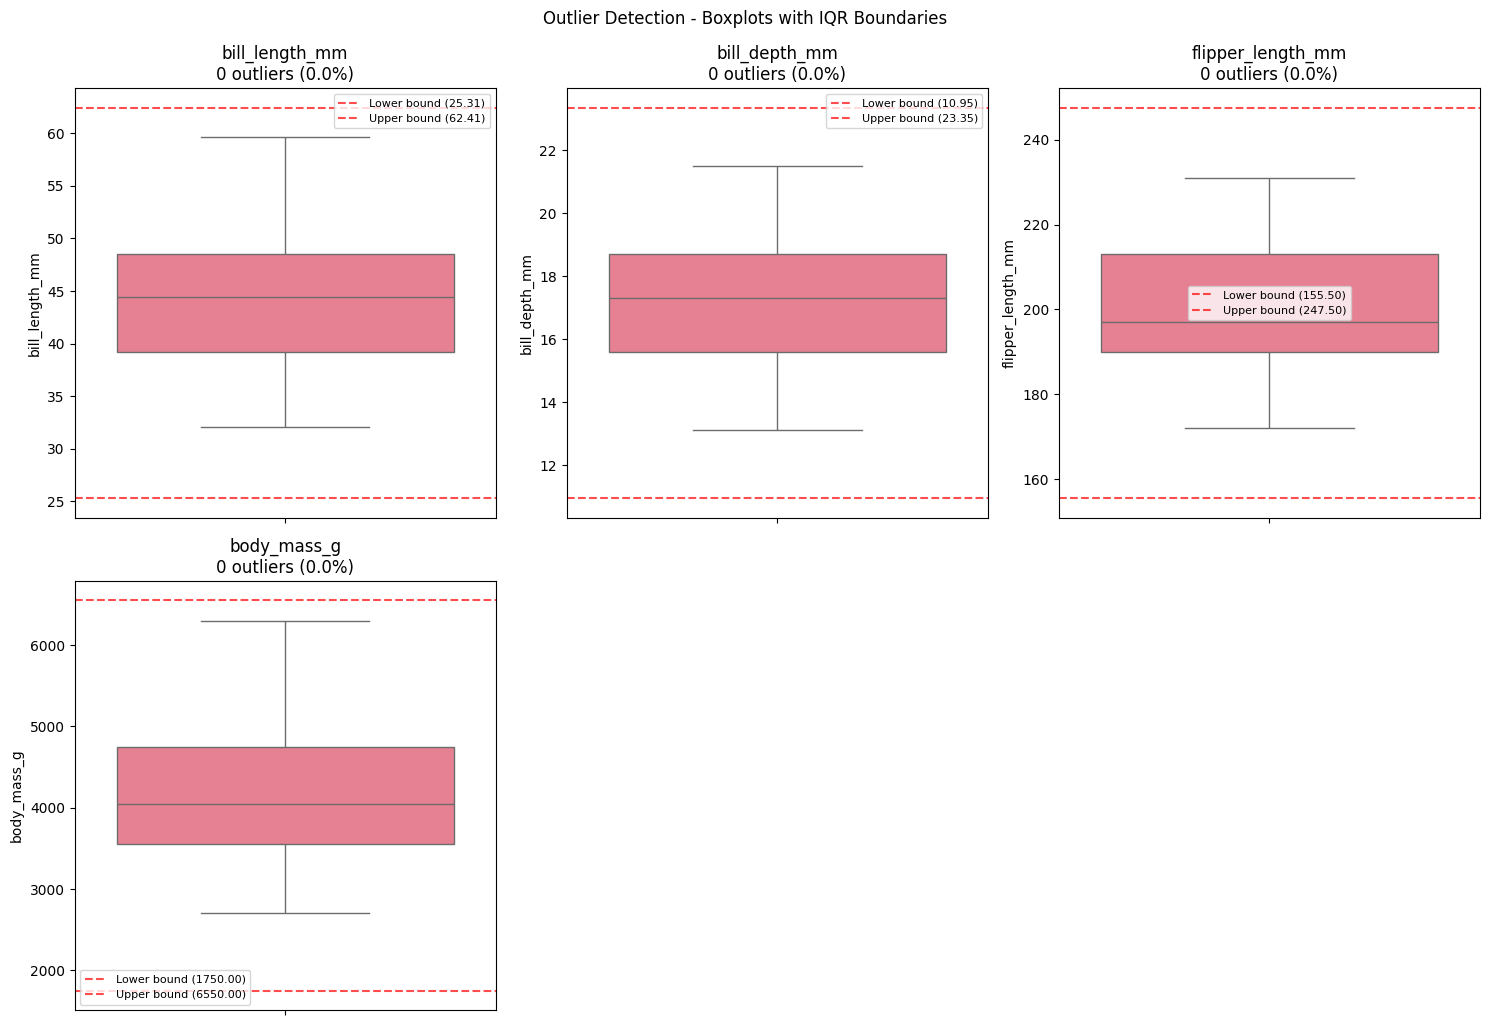

In [42]:
# Visualize outliers with boxplots and boundary annotations
if len(numeric_cols) > 0:
    # Create subplots for boxplots to visualize outliers
    n_cols = len(numeric_cols)
    fig, axes = plt.subplots(nrows=(n_cols + 2) // 3, ncols=3, figsize=(15, 5 * ((n_cols + 2) // 3)))
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for i, col in enumerate(numeric_cols):
        # Create boxplot
        sns.boxplot(y=df[col], ax=axes[i])
        
        # Get outlier boundaries from previously calculated summary
        lower_bound = outlier_summary[col]['lower_bound']
        upper_bound = outlier_summary[col]['upper_bound']
        outlier_count = outlier_summary[col]['count']
        outlier_pct = outlier_summary[col]['percentage']
        
        # Add horizontal lines for outlier boundaries
        axes[i].axhline(lower_bound, color='red', linestyle='--', alpha=0.7, label=f'Lower bound ({lower_bound:.2f})')
        axes[i].axhline(upper_bound, color='red', linestyle='--', alpha=0.7, label=f'Upper bound ({upper_bound:.2f})')
        
        axes[i].set_title(f'{col}\n{outlier_count} outliers ({outlier_pct}%)')
        axes[i].set_ylabel(col)
        axes[i].legend(fontsize=8)
    
    # Hide empty subplots
    for i in range(n_cols, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Outlier Detection - Boxplots with IQR Boundaries', y=1.02)
    plt.show()

    # Optional: Uncomment to remove outliers
    # print('\nTo remove outliers, uncomment the following:')
    # print('# for col in numeric_cols:')
    # print('#     Q1 = df[col].quantile(0.25)')
    # print('#     Q3 = df[col].quantile(0.75)')
    # print('#     IQR = Q3 - Q1')
    # print('#     lower_bound = Q1 - 1.5 * IQR')
    # print('#     upper_bound = Q3 + 1.5 * IQR')
    # print('#     df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]')
    # print('# print(f"Shape after removing outliers: {df.shape}")')

## Milestone 7: Exploratory Data Analysis (EDA)

Create comprehensive visualizations to understand data distributions, relationships, and patterns. This includes both univariate and multivariate analysis.

**Instructions:**
- Generate distribution plots for all numeric columns
- Create frequency plots for categorical columns
- Explore relationships between variables using correlation matrices and pair plots
- Identify patterns, trends, and potential insights
- Document key findings from the visualizations

Numeric columns: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical columns: ['species', 'island', 'sex']
Total columns analyzed: 7

=== NUMERIC DISTRIBUTIONS ===


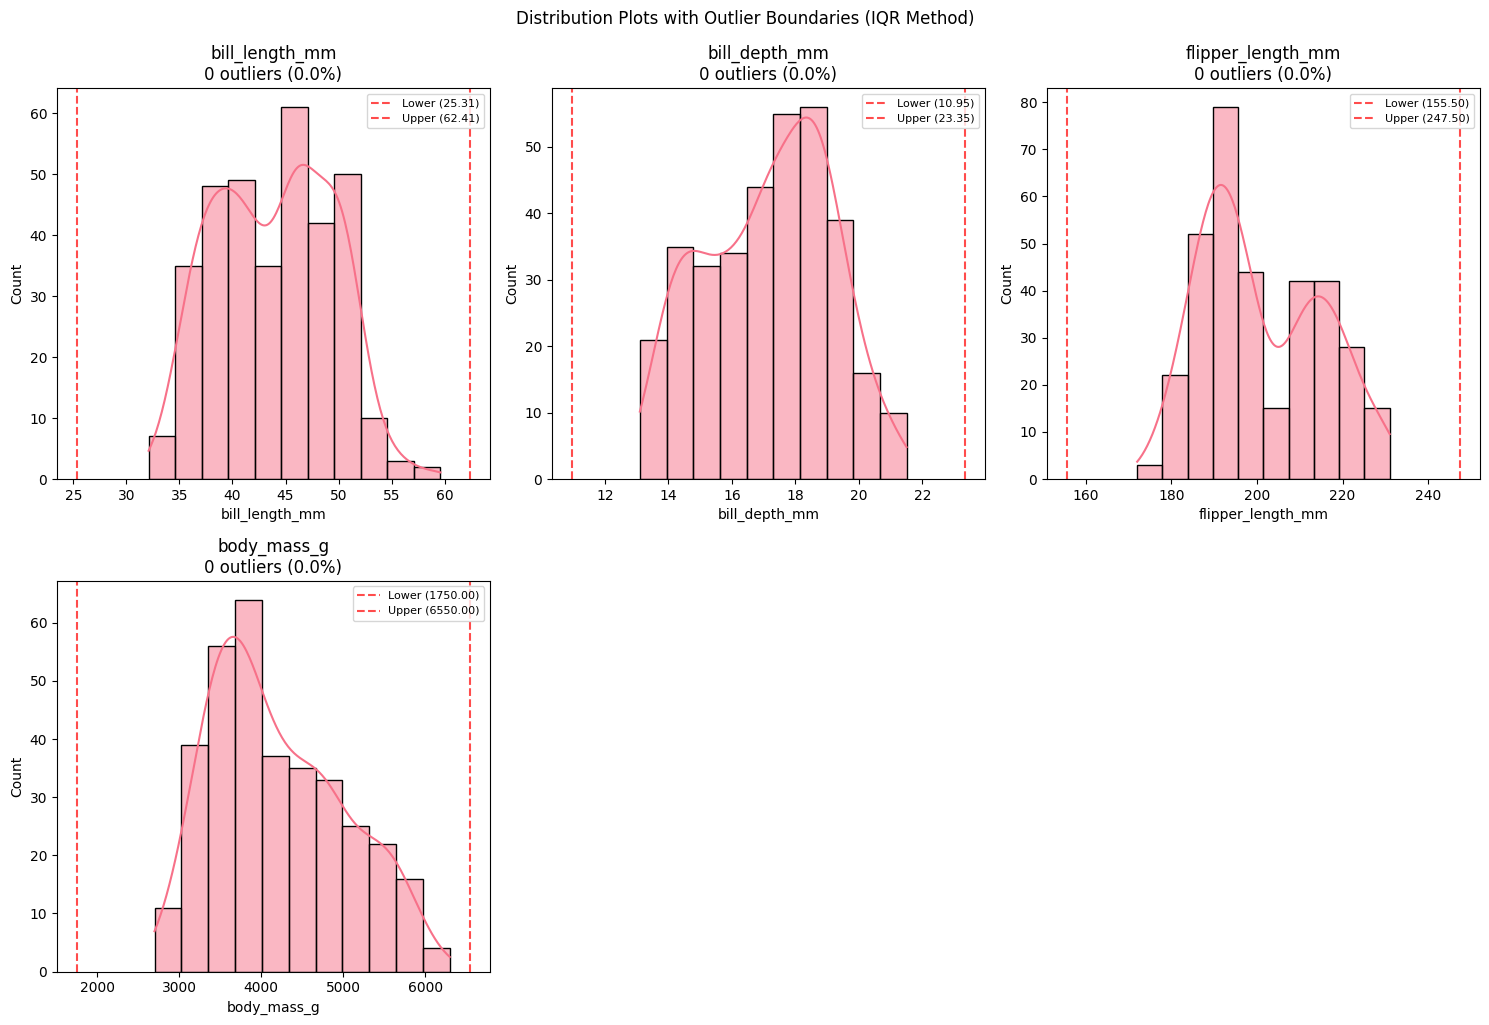


=== CATEGORICAL FREQUENCIES ===


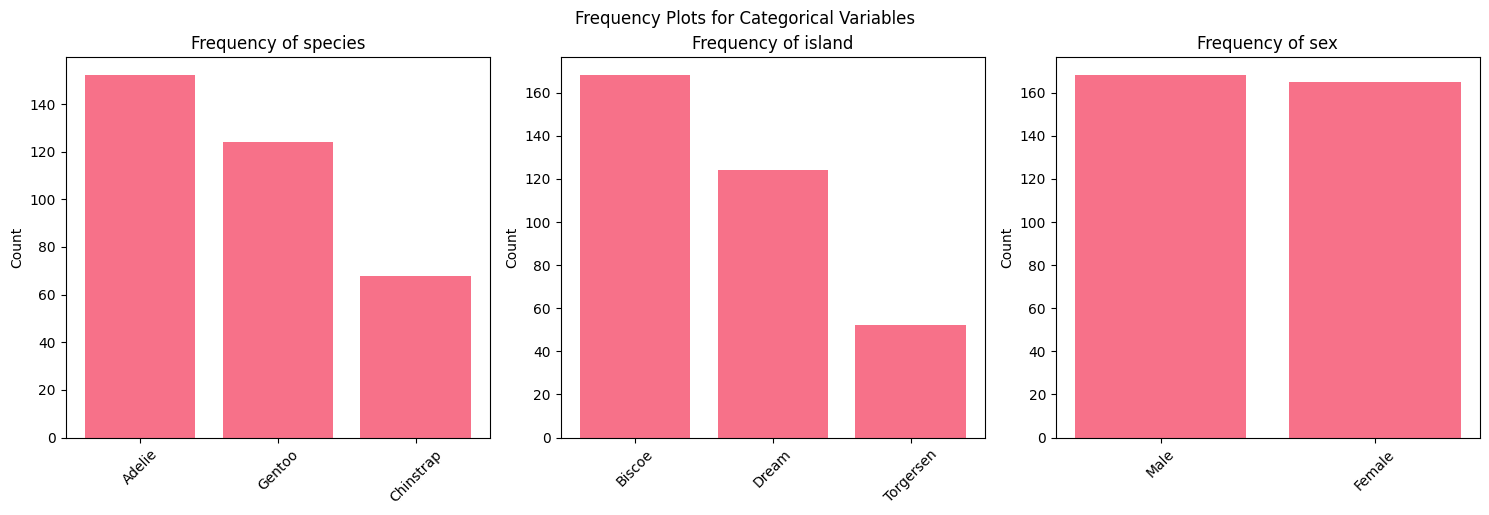


=== CORRELATION ANALYSIS ===


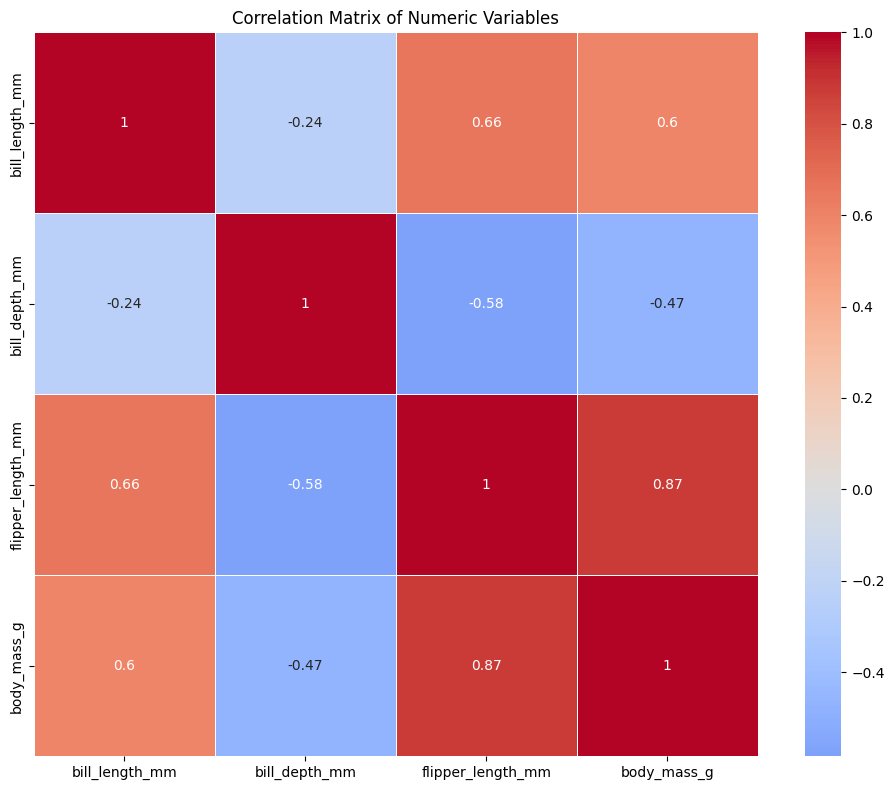


=== PAIRWISE RELATIONSHIPS ===


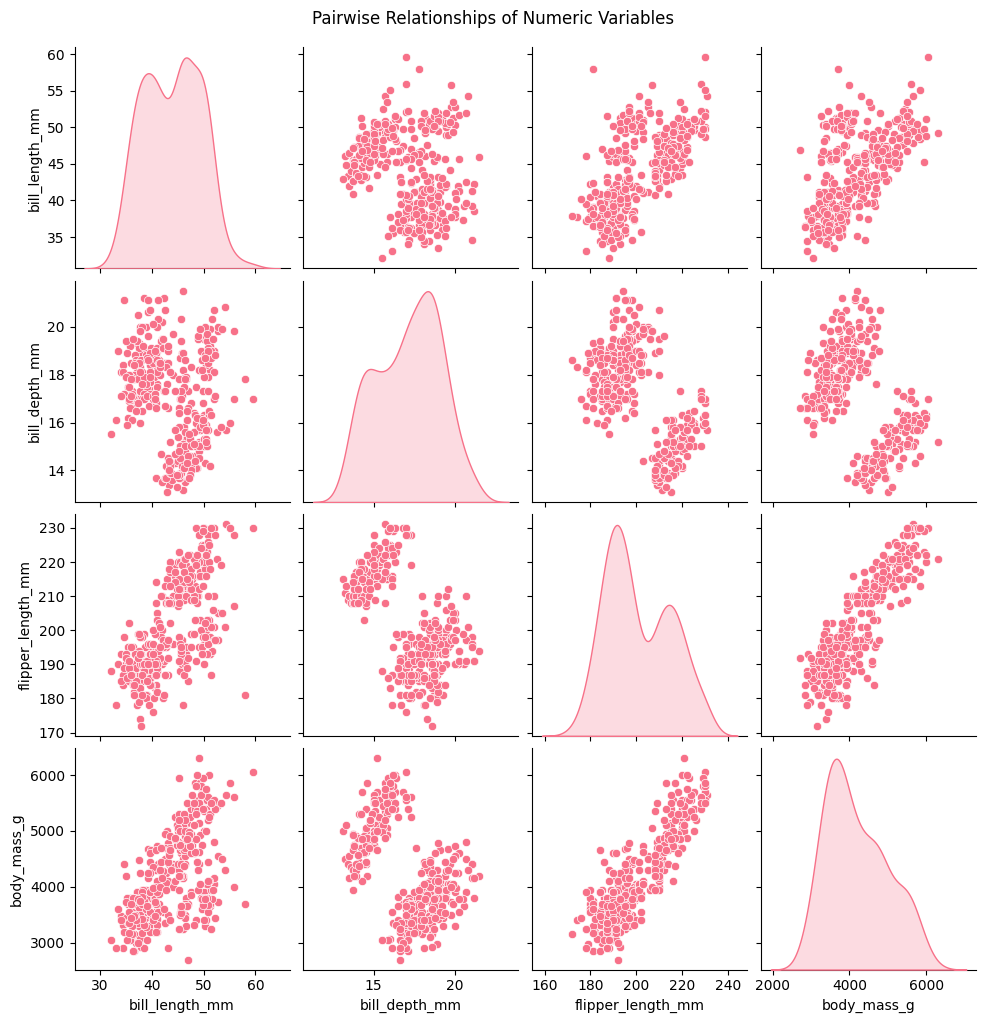


=== EDA COMPLETE ===
Analyzed 4 numeric and 3 categorical columns


In [43]:
# Perform comprehensive Exploratory Data Analysis
perform_eda(df, show_outlier_boundaries=True, max_pairplot_cols=5)

In [44]:
# Optional: Customize EDA parameters if needed
# perform_eda(df, show_outlier_boundaries=False, max_pairplot_cols=3)

# Optional: Additional specific analysis can be added here
# For example, if you want to create custom visualizations beyond the standard EDA
print("EDA complete. Add any additional custom analysis below as needed.")

EDA complete. Add any additional custom analysis below as needed.
